# Extract Transform Load all at once
This script is about to load data from my google drive, then perferm augmentation on these data and then load it back to new transformation.



In [4]:
!pip install pytorch-lightning albumentations opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.3 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paths declaration
We have two noticeable things:
1. But because due too its enormous volume of the dataset. Im gonna leave every raw image in raw folder, and augmented data will be stored in processed folder.
2. Therefore, when we encouter training step, we might want to grasp the data from both folders with predefined ratio

In [7]:
import os

DATA_PATH = os.path.join("drive","MyDrive","DataLake")
RAW_ROOT  = os.path.join("drive","MyDrive","DataLake", "01_raw")
SAVE_ROOT = os.path.join("drive","MyDrive","DataLake", "02_processed")

SPLITS    = ["Train", "Test"]
CLASSES   = ["Overripe", "Ripe", "Unripe"]
IMG_SIZE  = 224
VAL_SPLIT = 0.2
SEED      = 42


## Augmentation Pipeline

When it comes to image augmentation, it is obvious that it might help our model perform and generalize better in reallife (i hope so). Moreover, these methods might enable our model to withstand the distribution shift from trained data to real life data.

Because our data is huge, so i want that the model just tranform a portion of raw image for experiment. We also keep track of it by using one json files so that we can do some statistics later

In [9]:
import os
import cv2
import json
import numpy as np
from datetime import datetime

# Pipelines
resize_transform = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])
augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.RandomBrightnessContrast(p=0.5),
    A.Rotate(limit=20, p=0.5)
])

def process_with_predefined_logic(aug_proportion=0.3):
    transformation_diary = {}

    for split in SPLITS:
        for cls in CLASSES:
            input_dir = os.path.join(RAW_ROOT, split, cls)
            output_dir = os.path.join(SAVE_ROOT, split, cls)
            os.makedirs(output_dir, exist_ok=True)

            if not os.path.exists(input_dir): continue

            files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

            # 1. PRE-CALCULATE: Create a list of decisions (True = augment, False = no augment)
            # Only apply to 'Train' split
            if split == "Train":
                num_files = len(files)
                # Create random mask based on proportion
                decisions = np.random.rand(num_files) < aug_proportion
            else:
                decisions = [False] * len(files)

            # 2. PROCESS BASED ON DECISIONS
            for idx, img_name in enumerate(files):
                image = cv2.imread(os.path.join(input_dir, img_name))
                if image is None: continue

                # Base resize
                base_img = resize_transform(image=image)["image"]
                cv2.imwrite(os.path.join(output_dir, img_name), base_img)

                # Augmented version (if decided)
                if decisions[idx]:
                    aug_img = augmentation_pipeline(image=image)["image"]
                    name, ext = os.path.splitext(img_name)
                    aug_filename = f"{name}_aug{ext}"
                    cv2.imwrite(os.path.join(output_dir, aug_filename), aug_img)

                    # Update Diary
                    transformation_diary[aug_filename] = {
                        "original": img_name,
                        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    }

    # 3. Save Diary to JSON
    diary_path = os.path.join(SAVE_ROOT, "transformation_diary.json")
    with open(diary_path, 'w') as f:
        json.dump(transformation_diary, f, indent=4)

    print(f"Processing complete. Diary saved to {diary_path}")


In [10]:
process_with_predefined_logic(aug_proportion=0.3)

Processing complete. Diary saved to drive/MyDrive/DataLake/02_processed/transformation_diary.json


## Sanity check

In [11]:
import os
import json
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

# --- Sanity Check Function ---

def perform_sanity_check(save_root, diary_filename="transformation_diary.json"):
    diary_path = os.path.join(save_root, diary_filename)

    if not os.path.exists(diary_path):
        print("Diary file not found. Please run the processing script first.")
        return

    with open(diary_path, 'r') as f:
        diary = json.load(f)

    # 1. Statistics
    data = []
    for aug_file, info in diary.items():
        # Infer split and class from the path structure: SAVE_ROOT/Split/Class/...
        # Assuming path structure: SAVE_ROOT/Split/Class/image.jpg
        # We need to backtrack from the file to find where it lives
        for split in ["Train", "Test"]:
            for cls in ["Overripe", "Ripe", "Unripe"]:
                folder = os.path.join(save_root, split, cls)
                if os.path.exists(os.path.join(folder, aug_file)):
                    data.append({"split": split, "class": cls, "type": "augmented"})

    df = pd.DataFrame(data)

    # Plotting Stats
    if not df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Chart 1: Augmented count by Class
        df.groupby(["split", "class"]).size().unstack().plot(kind='bar', ax=axes[0])
        axes[0].set_title("Number of Augmented Images per Class/Split")
        axes[0].set_ylabel("Count")

        # Chart 2: Proportion check
        df["split"].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1])
        axes[1].set_title("Augmentation Split Proportion")

        plt.tight_layout()
        plt.show()
    else:
        print("No augmented images found in the diary.")

    # 2. Visualize Random Images
    print("\nDisplaying random images from processed folders:")
    for split in ["Train", "Test"]:
        for cls in ["Overripe", "Ripe", "Unripe"]:
            folder = os.path.join(save_root, split, cls)
            if not os.path.exists(folder): continue

            files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]
            if not files: continue

            # Select 1 random image
            rand_file = random.choice(files)
            img = cv2.imread(os.path.join(folder, rand_file))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Fix colors for matplotlib

            plt.figure(figsize=(3, 3))
            plt.imshow(img)
            plt.title(f"{split} - {cls}\n{rand_file}")
            plt.axis('off')
            plt.show()



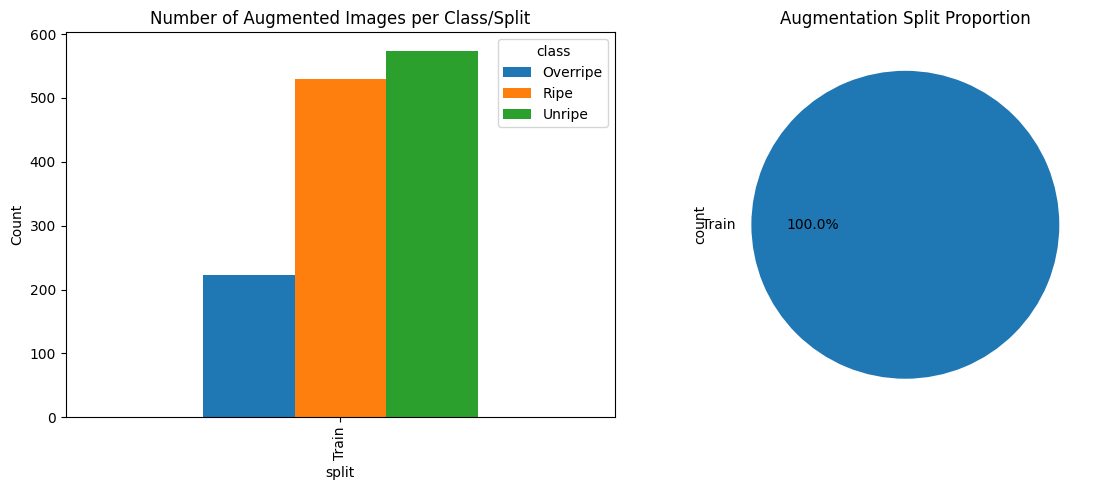


Displaying random images from processed folders:


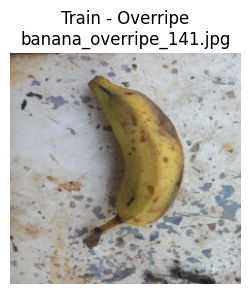

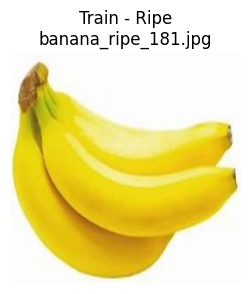

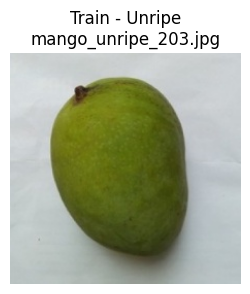

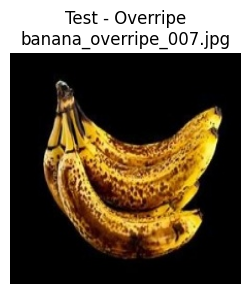

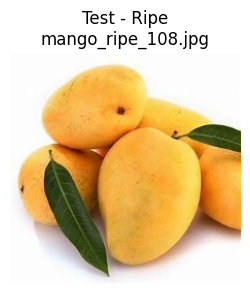

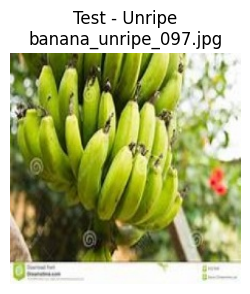

In [12]:
# Run the check
perform_sanity_check(SAVE_ROOT)